# **Project: Unsupervised Fraud Detection in MOT Datasets**

**Objective:** To identify fraud (subtle odometer manipulation) within UK MOT records using behavioral anomaly detection.

* Unsupervised Models: Comparative analysis of Isolation Forest, One-Class SVM, Local Outlier Factor, and Elliptic Envelope.

* Scientific Validation: Model performance was evaluated against injected synthetic anomalies to measure Precision (false alarm rate) and Recall (detection rate).

**Goal:** Determine which algorithm most effectively identifies subtle fraud patterns

**Dataset Description:** DVSA MOT Test Records
Source: Official UK Government (DVSA) MOT testing data.

Data Scope:

 * Core Features: Includes vehicle_id, test_date, and test_mileage.

 * Contains vehicle specifics such as make, model, and fuel_type,.

 * The longitudinal nature of the data (multiple tests over years for the same vehicle) allows for the creation of time-series behavioral features.

 # Data Loading & Environment Setup



*   Mounting Drive





In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


* loading Dataset

In [2]:
import pandas as pd
output_path = "/content/drive/MyDrive/MOT/mot_2018_2024_10percent_by_vehicle.csv.gz"
df1 = pd.read_csv(output_path, low_memory=False)


* Importing libraries

In [112]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [113]:
df1.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,colour,fuel_type,cylinder_capacity,first_use_date,mot_year,completed_date
0,1886686693,133782560,2018-01-01,4,NT,P,93737.0,B,ROVER,75,BLUE,DI,1951.0,2003-11-27,2018,NaN
1,649880599,1359750734,2018-01-01,4,NT,P,87226.0,B,MERCEDES-BENZ,B,BLUE,DI,1991.0,2007-06-28,2018,NaN
2,393989683,1145230428,2018-01-01,4,NT,P,112663.0,LU,BMW,3 SERIES,RED,PE,2497.0,2006-07-24,2018,NaN
3,1967504823,1017819996,2018-01-01,4,NT,P,174561.0,PR,BMW,530,GREY,DI,2926.0,2003-03-31,2018,NaN
4,180747253,1161058062,2018-01-01,4,NT,P,39556.0,B,MAZDA,2,RED,PE,1349.0,2009-10-16,2018,NaN


# Data Sampling

* "performing unique vehicle-id sampling to create a manageable subset for behavioral analysis."

In [345]:

vehicle_ids = df1["vehicle_id"].unique()
sample_ids = np.random.choice(
    vehicle_ids,
    size=40000,
    replace=False
)

In [346]:
df = df1[df1["vehicle_id"].isin(sample_ids)]

In [347]:
df.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,colour,fuel_type,cylinder_capacity,first_use_date,mot_year,completed_date
43,1855334799,1347905358,2018-01-01,4,NT,P,135638.0,CB,MITSUBISHI,SHOGUN,BLUE,DI,2477.0,1992-12-31,2018,NaN
95,1473837333,804824704,2018-01-02,7,NT,P,88736.0,NN,LAND ROVER,DEFENDER,WHITE,DI,2495.0,2006-12-12,2018,NaN
105,726418861,945956584,2018-01-02,4,NT,P,132811.0,CV,HONDA,CIVIC,BLUE,DI,2204.0,2008-03-28,2018,NaN
152,1963224955,1264003808,2018-01-02,4,NT,P,35198.0,BH,SMART (MCC),FORTWO COUPE,SILVER,PE,999.0,2011-09-30,2018,NaN
175,1384061519,336571628,2018-01-02,4,NT,F,203494.0,GU,BMW,3 SERIES,SILVER,DI,1995.0,2002-01-04,2018,NaN


Sorting the dataset by vehicle id and test dates

In [348]:
df = df.sort_values(
    ["vehicle_id", "test_date"]
)
df = df.reset_index(drop=True)

Poisoning the dataset to create a testing dataset for models validation.

*   here we will pick randomly 600 vehicles and add 5000 miles in there previous year MOT mileage reading to create a fraud dataset later we will label them as fraud and use them in our testing datset.
*   here we will create a coloumn synthetic label where we will name the poisoned data as clocked commuters and remaining dataset we will name them as normal.




In [349]:
# # 1. Get unique vehicles
# unique_cars = df['vehicle_id'].unique()

# # 2. Select 600 vehicles to turn into "Suspects"
# np.random.seed(42)
# suspect_vids = np.random.choice(unique_cars, size=600, replace=False)

# # --- NEW: Split suspects into two different fraud types ---
# group_rollback = suspect_vids[:0]
# group_commuter = suspect_vids[0:]

# # Mark EVERYTHING as Normal first
# df['synthetic_label'] = 'Normal'

# # 3. Sort to ensure we are modifying the LATEST record
# df = df.sort_values(['vehicle_id', 'test_date'])

# # 4. Inject Synthetic Fraud
# for vid in suspect_vids:
#     idx_list = df[df['vehicle_id'] == vid].index
#     if len(idx_list) < 2: continue

#     last_idx = idx_list[-1]
#     prev_idx = idx_list[-2]
#     prev_mileage = df.at[prev_idx, 'test_mileage']

#     # --- PERSONA 1: The Rollback (-10,000 miles) ---
#     if vid in group_rollback:
#         df.at[last_idx, 'test_mileage'] = max(0, prev_mileage - 10000)
#         df.at[last_idx, 'synthetic_label'] = 'Rollback'

#     # --- PERSONA 2: The Clocked Commuter (Subtle +500 miles) ---
#     elif vid in group_commuter:
#         # We give them a tiny increase so it's not negative,
#         # but it will crash their 'usage_trend_shift'
#         df.at[last_idx, 'test_mileage'] = prev_mileage + 5000
#         df.at[last_idx, 'synthetic_label'] = 'Clocked_Commuter'

In [350]:
# 1. Get unique vehicles
unique_cars = df['vehicle_id'].unique()

# 2. Select 600 vehicles to turn into "Clocked Commuters"
np.random.seed(42)
suspect_vids = np.random.choice(unique_cars, size=600, replace=False)

# 3. Mark everything as Normal first
df['synthetic_label'] = 'Normal'

# 4. Sort to ensure we are modifying the LATEST record
df = df.sort_values(['vehicle_id', 'test_date'])

# 5. Inject Synthetic Fraud (Clocked Commuter Persona)
for vid in suspect_vids:
    # Get all indices for this vehicle
    idx_list = df[df['vehicle_id'] == vid].index

    # We need at least 2 records to create a trend shift
    if len(idx_list) < 2:
        continue

    last_idx = idx_list[-1]
    prev_idx = idx_list[-2]
    prev_mileage = df.at[prev_idx, 'test_mileage']

    # --- PERSONA: The Clocked Commuter ---
    # We add a small amount (5,000 miles) so the mileage doesn't go backwards,
    # but the 'miles_per_day' and 'usage_trend_shift' will drop significantly.
    df.at[last_idx, 'test_mileage'] = prev_mileage + 4343
    df.at[last_idx, 'synthetic_label'] = 'Clocked_Commuter'

print(f"Injection complete: 600 Clocked Commuter personas created.")

Injection complete: 600 Clocked Commuter personas created.


# Data Pre-processing and Feature Engineering

* Standardizing dates to datetime formate.
* sorting dataframe by vehicle id and test dates.
* this step is crutial for calculating the miles_per_day and mileage_diff features which we use later in the anomaly detection.

In [351]:
# Convert date
df["test_date"] = pd.to_datetime(df["test_date"], errors="coerce")

# Sort properly
df = df.sort_values(["vehicle_id", "test_date"])

# Reset index
df = df.reset_index(drop=True)

print(" Data sorted properly")
df.head(10)

 Data sorted properly


,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,colour,fuel_type,cylinder_capacity,first_use_date,mot_year,completed_date,synthetic_label
0,377057623,88266,2018-01-03,4,NT,F,104685.0,BB,TOYOTA,YARIS,SILVER,PE,998.0,2005-09-02,2018,NaN,Normal
1,421052679,88266,2018-01-08,4,RT,P,104686.0,BB,TOYOTA,YARIS,SILVER,PE,998.0,2005-09-02,2018,NaN,Normal
2,579070727,107312,2018-04-04,4,NT,PRS,98682.0,BD,HONDA,JAZZ,BLUE,PE,1246.0,2005-07-12,2018,NaN,Normal
3,1788230729,107312,2019-03-18,4,NT,F,106261.0,BD,HONDA,JAZZ,BLUE,PE,1246.0,2005-07-12,2019,NaN,Normal
4,1870654745,107312,2019-03-20,4,NT,P,106322.0,HD,HONDA,JAZZ,BLUE,PE,1246.0,2005-07-12,2019,NaN,Normal
5,988992509,162901,2024-10-07,4,NT,P,30692.0,CH,MERCEDES-BENZ,A,SILVER,DI,1461.0,2019-08-29,2024,2024-10-07T09:01:01.000Z,Normal
6,228672091,327502,2018-09-21,4,NT,F,29533.0,NE,MAZDA,2,MAROON,PE,1498.0,2011-03-04,2018,NaN,Normal
7,1408593423,327502,2018-09-21,4,RT,P,29533.0,NE,MAZDA,2,MAROON,PE,1498.0,2011-03-04,2018,NaN,Normal
8,988887505,327502,2019-09-09,4,NT,P,31438.0,NE,MAZDA,2,MAROON,PE,1498.0,2011-03-04,2019,NaN,Normal
9,650975429,327502,2020-09-21,4,NT,P,33101.0,NE,MAZDA,2,MAROON,PE,1498.0,2011-03-04,2020,NaN,Normal


# Core features

* Now that we have sorted our dataset, we will see how the car has been driven between each MOT test

**What we are creating here**


*   Previous Mileage: previous mot test mileage.
*   Mileage difference: difference of mileage between previous and current MOT test.
*   Days difference: Days differnce between previoius MOT test and current MOT test.
*   Miles per day: This is the most important feature it will tell us the how many miles car have been driven from previous till currunt MOT on daily basis. which will give us the intensity of the car use



In [352]:
# Previous mileage
df["prev_mileage"] = df.groupby("vehicle_id")["test_mileage"].shift(1)

# Mileage difference
df["mileage_diff"] = df["test_mileage"] - df["prev_mileage"]

# Days difference
df["prev_test_date"] = df.groupby("vehicle_id")["test_date"].shift(1)
df["days_diff"] = (df["test_date"] - df["prev_test_date"]).dt.days
df = df[df["days_diff"] > 0]
# Miles per day
df["miles_per_day"] = df["mileage_diff"] / df["days_diff"]

print("Core features created")
df[["vehicle_id","test_mileage","prev_mileage","mileage_diff","days_diff","miles_per_day"]].head(10)

Core features created


,vehicle_id,test_mileage,prev_mileage,mileage_diff,days_diff,miles_per_day
1,88266,104686.0,104685.0,1.0,5.0,0.200000
3,107312,106261.0,98682.0,7579.0,348.0,21.778736
4,107312,106322.0,106261.0,61.0,2.0,30.500000
8,327502,31438.0,29533.0,1905.0,353.0,5.396601
9,327502,33101.0,31438.0,1663.0,378.0,4.399471
10,327502,34593.0,33101.0,1492.0,365.0,4.087671
11,327502,40148.0,34593.0,5555.0,1098.0,5.059199
14,384010,76999.0,69662.0,7337.0,367.0,19.991826
15,384010,83628.0,76999.0,6629.0,369.0,17.964770
16,384010,88596.0,83628.0,4968.0,352.0,14.113636


* Detecting Behavioral Shifts (Year-over-Year)




**Finding the sneaky Rollbacks.**
* In this section we will compare the vehicle intensity of driving to its own performance in previous year.
* A car might show a positive milage for example 3000, but if it was doing 15000 mile every year previously that sudden drop could be a major red flag.
* **Usage Trend Shift**: this feature will create a ratio of current year mileage speed and previous year milage speed.
* A value of near 0 mean usage rate drop which is common odometer temparing and near 1 mean car is driven consistently.

In [353]:
# Compare current usage to the PREVIOUS year's usage specifically
df['prev_year_miles_per_day'] = df.groupby('vehicle_id')['miles_per_day'].shift(1)
df['usage_trend_shift'] = df['miles_per_day'] / df['prev_year_miles_per_day']

In [354]:
df.head(10)

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,mot_year,completed_date,synthetic_label,prev_mileage,mileage_diff,prev_test_date,days_diff,miles_per_day,prev_year_miles_per_day,usage_trend_shift
1,421052679,88266,2018-01-08,4,RT,P,104686.0,BB,TOYOTA,YARIS,...,2018,NaN,Normal,104685.0,1.0,2018-01-03,5.0,0.200000,NaN,NaN
3,1788230729,107312,2019-03-18,4,NT,F,106261.0,BD,HONDA,JAZZ,...,2019,NaN,Normal,98682.0,7579.0,2018-04-04,348.0,21.778736,NaN,NaN
4,1870654745,107312,2019-03-20,4,NT,P,106322.0,HD,HONDA,JAZZ,...,2019,NaN,Normal,106261.0,61.0,2019-03-18,2.0,30.500000,21.778736,1.400449
8,988887505,327502,2019-09-09,4,NT,P,31438.0,NE,MAZDA,2,...,2019,NaN,Normal,29533.0,1905.0,2018-09-21,353.0,5.396601,NaN,NaN
9,650975429,327502,2020-09-21,4,NT,P,33101.0,NE,MAZDA,2,...,2020,NaN,Normal,31438.0,1663.0,2019-09-09,378.0,4.399471,5.396601,0.815230
10,1699918631,327502,2021-09-21,4,NT,P,34593.0,NE,MAZDA,2,...,2022,NaN,Normal,33101.0,1492.0,2020-09-21,365.0,4.087671,4.399471,0.929128
11,1408345249,327502,2024-09-23,4,RT,P,40148.0,NE,MAZDA,2,...,2024,2024-09-23T12:59:29.000Z,Normal,34593.0,5555.0,2021-09-21,1098.0,5.059199,4.087671,1.237673
14,1467309127,384010,2019-01-24,4,NT,P,76999.0,NW,RENAULT,MEGANE,...,2019,NaN,Normal,69662.0,7337.0,2018-01-22,367.0,19.991826,NaN,NaN
15,429468945,384010,2020-01-28,4,NT,P,83628.0,NW,RENAULT,MEGANE,...,2020,NaN,Normal,76999.0,6629.0,2019-01-24,369.0,17.964770,19.991826,0.898606
16,1807362753,384010,2021-01-14,4,NT,P,88596.0,NW,RENAULT,MEGANE,...,2022,NaN,Normal,83628.0,4968.0,2020-01-28,352.0,14.113636,17.964770,0.785629


* checking the shape of our dataset.

In [355]:
df.shape

(116921, 24)

* here we will keep the rows where if the days differnce between previous MOT and current MOT is greater than 0.

In [356]:
df = df[df["days_diff"] > 0]
df = df.dropna(subset=["mileage_diff", "days_diff"])

print(" Cleaned dataset shape:", df.shape)

 Cleaned dataset shape: (114881, 24)


* Checking if there are any null values in our Dataset.

In [357]:
df.isnull().sum()

,0
test_id,0
vehicle_id,0
test_date,0
test_class_id,0
test_type,0
test_result,0
test_mileage,0
postcode_area,0
make,0
model,0


In [358]:
df.columns

Index(['test_id', 'vehicle_id', 'test_date', 'test_class_id', 'test_type',
       'test_result', 'test_mileage', 'postcode_area', 'make', 'model',
       'colour', 'fuel_type', 'cylinder_capacity', 'first_use_date',
       'mot_year', 'completed_date', 'synthetic_label', 'prev_mileage',
       'mileage_diff', 'prev_test_date', 'days_diff', 'miles_per_day',
       'prev_year_miles_per_day', 'usage_trend_shift'],
      dtype='object')

In [359]:
df.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,mot_year,completed_date,synthetic_label,prev_mileage,mileage_diff,prev_test_date,days_diff,miles_per_day,prev_year_miles_per_day,usage_trend_shift
1,421052679,88266,2018-01-08,4,RT,P,104686.0,BB,TOYOTA,YARIS,...,2018,NaN,Normal,104685.0,1.0,2018-01-03,5.0,0.200000,NaN,NaN
3,1788230729,107312,2019-03-18,4,NT,F,106261.0,BD,HONDA,JAZZ,...,2019,NaN,Normal,98682.0,7579.0,2018-04-04,348.0,21.778736,NaN,NaN
4,1870654745,107312,2019-03-20,4,NT,P,106322.0,HD,HONDA,JAZZ,...,2019,NaN,Normal,106261.0,61.0,2019-03-18,2.0,30.500000,21.778736,1.400449
8,988887505,327502,2019-09-09,4,NT,P,31438.0,NE,MAZDA,2,...,2019,NaN,Normal,29533.0,1905.0,2018-09-21,353.0,5.396601,NaN,NaN
9,650975429,327502,2020-09-21,4,NT,P,33101.0,NE,MAZDA,2,...,2020,NaN,Normal,31438.0,1663.0,2019-09-09,378.0,4.399471,5.396601,0.815230


Creating a variable car_age_at_test, This varible is important to tell us the car age at particular test.

In [360]:
df["test_date"] = pd.to_datetime(df["test_date"])
df["first_use_date"] = pd.to_datetime(df["first_use_date"])
df["car_age_at_test"] = (
    (df["test_date"] - df["first_use_date"])
    .dt.days / 365.25
)

Creaating to variables:


*   History average miles
*   Usage consistency Raio



In [361]:
# 1. Ensure data is sorted so the history flows correctly
df = df.sort_values(['vehicle_id', 'test_date'])

# 2. Calculate the Cumulative Average miles per day for each vehicle
# This gives us the "Normal" behavior for THAT specific car
df['hist_avg_miles_per_day'] = df.groupby('vehicle_id')['miles_per_day'].expanding().mean().reset_index(level=0, drop=True)

# 3. Create the Ratio (The Fraud Detector)
# If this is 1.0, the car is driven consistently.
# If it's 0.5, the car suddenly 'lost' half its daily usage.
df['usage_consistency_ratio'] = df['miles_per_day'] / df['hist_avg_miles_per_day']

In [362]:
df.isnull().sum()


,0
test_id,0
vehicle_id,0
test_date,0
test_class_id,0
test_type,0
test_result,0
test_mileage,0
postcode_area,0
make,0
model,0


Removing rows which dont have previous record available to detect behavoral pattern we need to have atleast previous year or previous mot entry of a vehicle.

In [363]:
# Create the 'is_first_record' flag based on your Null counts
df['is_first_record'] = df['prev_year_miles_per_day'].isna()

# Create your ML-Ready dataset (The 'Clean' rows)
# This removes the 16,438 rows that don't have enough history
df_ml = df[df['is_first_record'] == False].copy()

# Fix the 821 ratio errors by dropping them or filling with 1.0
# (Dropping is safer for fraud detection)
df_ml = df_ml.dropna(subset=['usage_consistency_ratio'])

print(f"Original rows: {len(df)}")
print(f"Rows ready for Fraud Detection: {len(df_ml)}")

Original rows: 114881
Rows ready for Fraud Detection: 81901


In [364]:
df_ml.isnull().sum()

,0
test_id,0
vehicle_id,0
test_date,0
test_class_id,0
test_type,0
test_result,0
test_mileage,0
postcode_area,0
make,0
model,0


**Box plot:**
* Creating box plot to check the high and low annual mileage user outliers in our dataset by using mileage differnce variable.

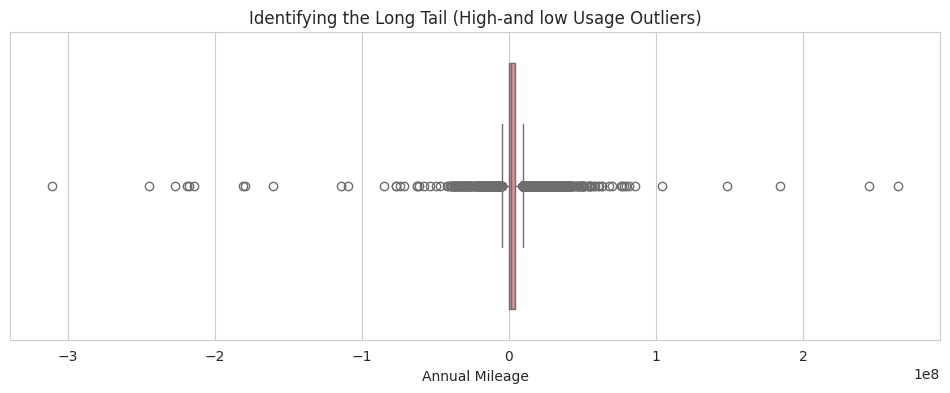

In [365]:
# Boxplot to visualize the "Long Tail" and outliers
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_ml['mileage_diff'] * 365, color='lightcoral')
plt.title('Identifying the Long Tail (High-and low Usage Outliers)')
plt.xlabel('Annual Mileage')
plt.show()



**Fuel Type vs Mileage differnce bar chart:**

* Here, we examine how mileage discrepancies vary across different fuel types.

* The data is grouped by fuel type, and the average mileage difference is calculated for each category.

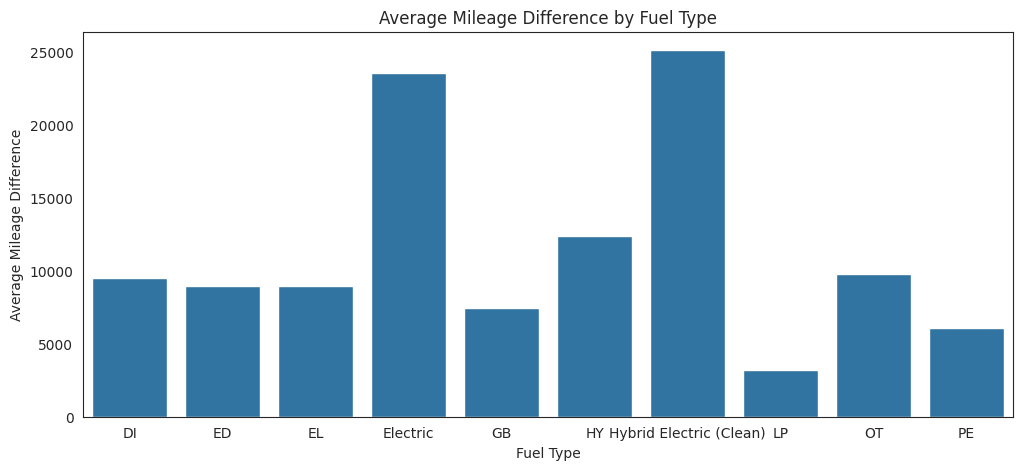

                 fuel_type  mileage_diff
0                       DI   9514.047085
1                       ED   8939.085714
2                       EL   8925.284746
3                 Electric  23520.162162
4                       GB   7422.333333
5                       HY  12390.115722
6  Hybrid Electric (Clean)  25124.410256
7                       LP   3228.695652
8                       OT   9758.181102
9                       PE   6107.120149


In [412]:
# Calculate average mileage_diff by fuel type
avg_mileage_fuel = df.groupby('fuel_type')['mileage_diff'].mean().reset_index()

# Plot
plt.figure(figsize=(12,5))
sns.barplot(data=avg_mileage_fuel, x='fuel_type', y='mileage_diff')
plt.title('Average Mileage Difference by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Mileage Difference')
plt.show()

print(avg_mileage_fuel)

**Car type vs Average annual Mileage differnce bar chart:**

* This section looks at how mileage changes vary across different vehicle brands.

* We first identify the top 15 most common brands in the dataset to keep the analysis focused and meaningful. Then, for each of these brands, we calculate the average mileage difference between tests.

/tmp/ipykernel_1620/3751136175.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_mileage_brand, x='make', y='mileage_diff', palette='viridis')


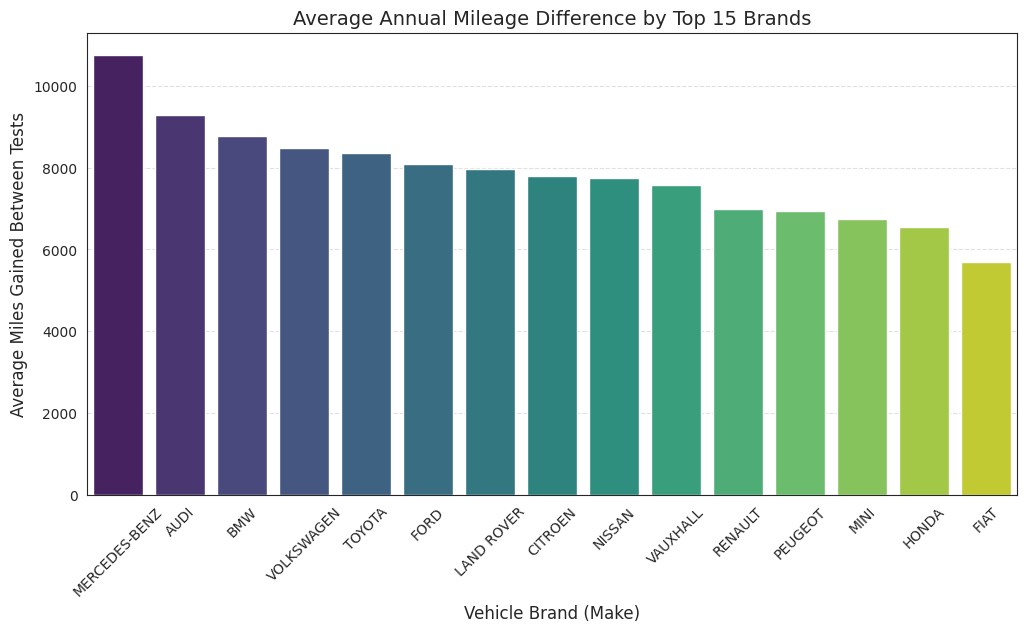

             make  mileage_diff
0   MERCEDES-BENZ  10761.786928
1            AUDI   9295.018651
2             BMW   8766.915603
3      VOLKSWAGEN   8482.853491
4          TOYOTA   8346.108602
5            FORD   8075.747776
6      LAND ROVER   7968.398511
7         CITROEN   7801.990800
8          NISSAN   7747.225255
9        VAUXHALL   7574.059259
10        RENAULT   6990.108726
11        PEUGEOT   6933.794401
12           MINI   6741.511188
13          HONDA   6553.672244
14           FIAT   5678.793768


In [413]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the top 15 most frequent brands in your dataset
top_brands = df['make'].value_counts().nlargest(15).index

# 2. Filter and calculate the average mileage difference per brand
avg_mileage_brand = df[df['make'].isin(top_brands)].groupby('make')['mileage_diff'].mean().sort_values(ascending=False).reset_index()

# 3. Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_mileage_brand, x='make', y='mileage_diff', palette='viridis')

plt.title('Average Annual Mileage Difference by Top 15 Brands', fontsize=14)
plt.xlabel('Vehicle Brand (Make)', fontsize=12)
plt.ylabel('Average Miles Gained Between Tests', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

# Print the values for your report
print(avg_mileage_brand)

**Distribution of Key Features:**

* In this section, we explore the distribution of two important variables: mileage difference and miles per day.

* To focus on realistic values and reduce the impact of extreme outliers, both variables are clipped to reasonable ranges:

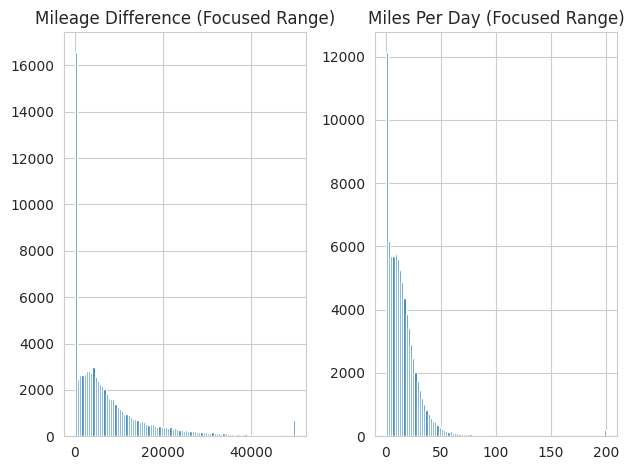

In [366]:
plt.figure()

# Mileage Difference (focus on realistic range)
plt.subplot(1, 2, 1)
df_ml['mileage_diff'].clip(0, 50000).hist(bins=100)
plt.title("Mileage Difference (Focused Range)")

# Miles Per Day
plt.subplot(1, 2, 2)
df_ml['miles_per_day'].clip(0, 200).hist(bins=100)
plt.title("Miles Per Day (Focused Range)")

plt.tight_layout()
plt.show()

if a car mileage at current mot is less than previous year mot we name it as negative mileage in our synthetic label coloumn which are obvious frauds later will use them in our testing dataset.

In [367]:
df_ml.loc[(df_ml['mileage_diff'] < 0) & (df_ml['synthetic_label'] == 'Normal'), 'synthetic_label'] = 'Negative_Mileage'

labeling the frauds as 1 and normal users as 0 such as negative annual mileage users and clocked commuters are actual fraud later we will seperate them from our dataset into testing dataset.

In [368]:
# 0 = The 'Honest' Baseline
# 1 = Any form of Anomaly (including Negative Mileage)
label_map = {
    'Normal': 0,
    'Clocked_Commuter': 1,
    'Rollback': 1,
    'Negative_Mileage': 1
}

df_ml['ground_truth'] = df_ml['synthetic_label'].map(label_map)

# Quick check to see your counts
print(df_ml['synthetic_label'].value_counts())

synthetic_label
Normal              81164
Negative_Mileage      420
Clocked_Commuter      317
Name: count, dtype: int64


# Creating testing dataset
*  The dataset is divided into normal and anomalous records.
*  Anomalies are identified using non-“Normal” labels or negative
mileage differences.
* All anomalous records are moved to a separate forensic test dataset.
* All anomalous records are moved to a separate forensic test dataset.
* The remaining normal records are kept as the main dataset for training.
* This ensures the model learns only from clean data and is tested on fraudulent cases.

In [369]:
# 1. Identify all Anomalies (Your 3 Personas + Natural Negatives)
# 'synthetic_label' will be 'Normal' for honest cars, and something else for suspects
is_anomaly = (df_ml['synthetic_label'] != 'Normal') | (df_ml['mileage_diff'] < 0)

# 2. Extract the Forensic Test Set (The Fraudsters)
df_forensic_test = df_ml[is_anomaly].copy()

# 3. Purify the main df_ml (The Honest Cars)
# We overwrite df_ml to contain only the 'Normal' records
df_ml = df_ml[~is_anomaly].copy()

print(f"--- Separation Complete ---")
print(f"Main dataset (df_ml) now has {len(df_ml)} clean records for training.")
print(f"Forensic dataset (df_forensic_test) has {len(df_forensic_test)} records for testing.")

--- Separation Complete ---
Main dataset (df_ml) now has 81164 clean records for training.
Forensic dataset (df_forensic_test) has 737 records for testing.


#Applying rules
Here we will use the DVSA 2013 statistical analysis rules to clean the dataset, our models need clean dataset for training.


*   Remove the rows where vehicles are driven more than 300 miles per day
*   Remove the rows where behaviour shift is less than 50% from previous year mileage till currunt year, if a driver drive the car less than 50% intensity from previous mot till current mot will be removed from the dataset.



In [370]:
import numpy as np

# 1. Define your Forensic Thresholds
behavioral_floor = 0.50  # Rule 2: Must keep at least 80% of usual driving pace
max_daily_limit = 300    # Rule 3: Must not exceed 300 miles per day

# 2. Apply the Three Forensic Rules to your dataset
# This creates the 'Gold Standard' version of df_ml
df_ml_clean = df_ml[
    # Rule 1: The Physical Rule (No going backwards)
    (df_ml['mileage_diff'] >= 0) &

    # Rule 2: The Behavioral Rule (The 80% Consistency Floor)
    (df_ml['usage_trend_shift'] >= behavioral_floor) &
    (df_ml['usage_trend_shift'] <= 1.20) & # Also cap it to avoid extreme jumps

    # Rule 3: The Statistical Rule (The 300 miles/day Ceiling)
    (df_ml['miles_per_day'] <= max_daily_limit)
].copy()

# 3. Clean up any remaining calculation errors (NaN or Infinity)
df_ml_clean = df_ml_clean.replace([np.inf, -np.inf], np.nan).dropna(subset=['usage_trend_shift', 'mileage_diff'])

# 4. Results for your presentation notes
print(f"Data Purification Complete.")
print(f"Original records: {len(df_ml)}")
print(f"Purified records: {len(df_ml_clean)}")
print(f"Suspicious/Bad data removed: {len(df_ml) - len(df_ml_clean)}")

Data Purification Complete.
Original records: 81164
Purified records: 34345
Suspicious/Bad data removed: 46819


In [371]:
df_ml= df_ml_clean.copy()

* A random sample of normal records is selected from the dataset.
* These samples are labelled as normal (ground truth = 0).
* The sampled normal data is combined with the anomaly dataset to create a balanced forensic test set.
* The test set is shuffled to mix normal and anomalous records.
* The selected normal samples and all anomalies are removed from the main dataset.
* This ensures the training dataset contains only pure normal data for model learning.

In [372]:
df_normal_samples = df_ml[df_ml['synthetic_label'] == 'Normal'].sample(n=2000, random_state=42).copy()
df_normal_samples['ground_truth'] = 0  # 0 means Normal

# 3. Combine them to create your Forensic Test Set
df_forensic_test = pd.concat([df_forensic_test, df_normal_samples])
# Shuffle so the 0s and 1s are mixed
df_forensic_test = df_forensic_test.sample(frac=1, random_state=42).reset_index(drop=True)

# 4. REMOVE these specific normal samples and ALL anomalies from df_ml
# This ensures df_ml is now a 'Pure Normal' training set
df_ml = df_ml[df_ml['synthetic_label'] == 'Normal'].drop(df_normal_samples.index)

In [373]:
df_forensic_test.isnull().sum()

,0
test_id,0
vehicle_id,0
test_date,0
test_class_id,0
test_type,0
test_result,0
test_mileage,0
postcode_area,0
make,0
model,0


# Checking Testing Dataset:


In [374]:
df_forensic_test['synthetic_label'].value_counts()


,count
synthetic_label,
Normal,2000
Negative_Mileage,420
Clocked_Commuter,317


In [375]:
df_ml=df_ml[df_ml["mileage_diff"] > 0]

**Heat Map (Corelation graph)**
* Selects only the numerical features from the dataset and computes a correlation matrix to examine the relationships between variables.

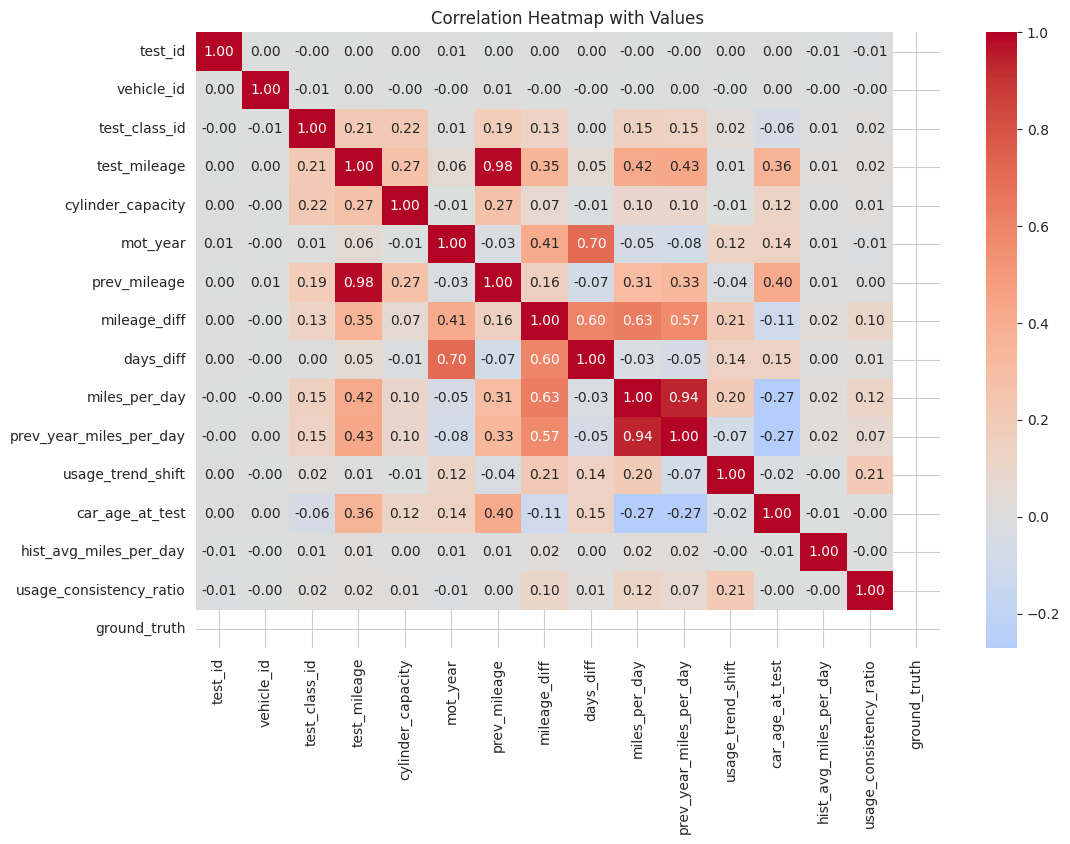

In [376]:

# Select numeric columns
df_numeric = df_ml.select_dtypes(include="number")

# Correlation matrix
corr_matrix = df_numeric.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap with Values")
plt.show()

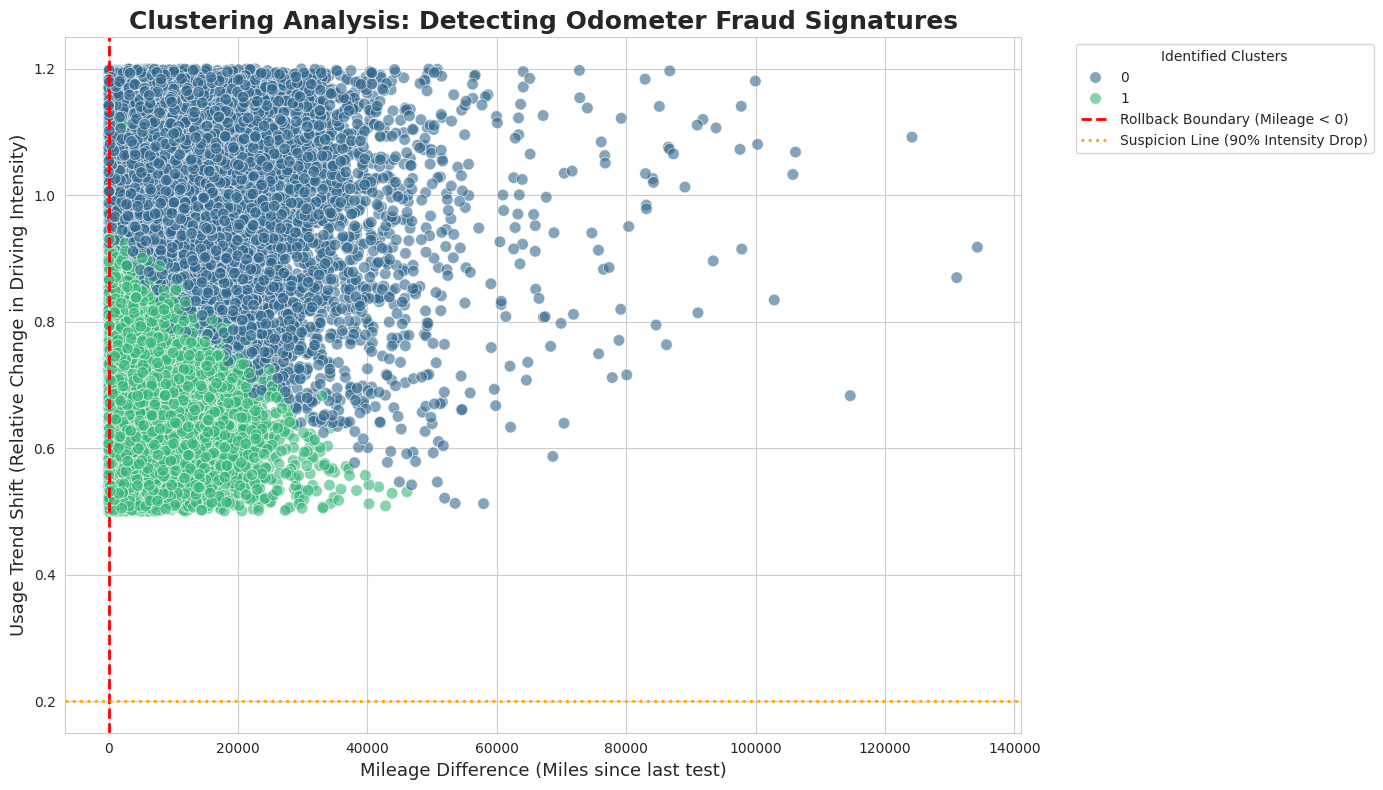

In [377]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. CLEANING & CAPPING (Fixing the ValueError)
df_viz = df_ml.copy()

# We replace Infinities with a fixed value (-10) so the Scaler can process them.
# This preserves the "signal" of a massive drop without breaking the math.
cols_to_fix = ['usage_trend_shift', 'usage_consistency_ratio']
df_viz[cols_to_fix] = df_viz[cols_to_fix].replace([np.inf, -np.inf], -10).fillna(0)

# 2. FEATURE SCALING
scaler = StandardScaler()
features_for_clustering = ['mileage_diff', 'usage_trend_shift', 'usage_consistency_ratio', 'car_age_at_test']
scaled_data = scaler.fit_transform(df_viz[features_for_clustering])

# 3. K-MEANS CLUSTERING (Pattern Discovery)
# We use 3 clusters: Normal, Obvious Fraud, and Sneaky Fraud
kmeans = KMeans(n_clusters=2, random_state=42)
df_viz['cluster'] = kmeans.fit_predict(scaled_data)

# 4. THE GRAPH (Visualizing the Fraud Signatures)
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Plotting Mileage Growth vs. Usage Shift
scatter = sns.scatterplot(
    data=df_viz,
    x='mileage_diff',
    y='usage_trend_shift',
    hue='cluster',
    palette='viridis',
    alpha=0.6,
    s=70
)

# Adding forensic reference lines
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Rollback Boundary (Mileage < 0)')
plt.axhline(y=0.2, color='orange', linestyle=':', linewidth=2, label='Suspicion Line (90% Intensity Drop)')

# Titles and Labels for the Meeting
plt.title('Clustering Analysis: Detecting Odometer Fraud Signatures', fontsize=18, fontweight='bold')
plt.xlabel('Mileage Difference (Miles since last test)', fontsize=13)
plt.ylabel('Usage Trend Shift (Relative Change in Driving Intensity)', fontsize=13)
plt.legend(title='Identified Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [378]:
df_ml.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,prev_test_date,days_diff,miles_per_day,prev_year_miles_per_day,usage_trend_shift,car_age_at_test,hist_avg_miles_per_day,usage_consistency_ratio,is_first_record,ground_truth
9,650975429,327502,2020-09-21,4,NT,P,33101.0,NE,MAZDA,2,...,2019-09-09,378.0,4.399471,5.396601,0.815230,9.552361,4.898036,0.898211,False,0
10,1699918631,327502,2021-09-21,4,NT,P,34593.0,NE,MAZDA,2,...,2020-09-21,365.0,4.087671,4.399471,0.929128,10.551677,4.627914,0.883264,False,0
15,429468945,384010,2020-01-28,4,NT,P,83628.0,NW,RENAULT,MEGANE,...,2019-01-24,369.0,17.964770,19.991826,0.898606,11.991786,18.978298,0.946595,False,0
16,1807362753,384010,2021-01-14,4,NT,P,88596.0,NW,RENAULT,MEGANE,...,2020-01-28,352.0,14.113636,17.964770,0.785629,12.955510,17.356744,0.813150,False,0
20,308744653,433062,2020-11-04,4,NT,P,59012.0,E,FORD,FIESTA,...,2019-04-29,555.0,14.439640,20.974359,0.688442,8.350445,17.706999,0.815476,False,0


# Models Training:

# Isolation forest
* Applies the Isolation Forest algorithm to detect anomalies based on selected behavioural features that may indicate fraudulent activity.
* The model is trained on the dataset and used to predict anomalies, where each record is labelled as either normal (1) or suspicious (-1). In addition, an anomaly score is calculated for each record, where lower (more negative) values indicate a higher likelihood of being fraudulent.

In [379]:
from sklearn.ensemble import IsolationForest

# 1. Define the 'Behavioral' features
# These are the columns that 'reveal' the fraud
features = [
    'mileage_diff',
    'miles_per_day',
    'usage_trend_shift',
    'usage_consistency_ratio',
    'car_age_at_test'
]

# 2. Initialize the model

# contamination=0.04 means we expect roughly 4% of the data to be 'weird'
iso_model = IsolationForest(contamination=0.04,n_estimators=100, random_state=42)

# 3. Predict Anomalies
# -1 = Suspicious / 1 = Normal
df_ml['anomaly_flag'] = iso_model.fit_predict(df_ml[features])

# 4. Get the 'Suspicion Score'
# Lower (more negative) scores mean the car is more likely to be fraudulent
df_ml['anomaly_score'] = iso_model.decision_function(df_ml[features])
print("Isolation forest Model training complete.")
print(f"Detected {len(df_ml[df_ml['anomaly_flag'] == -1])}  anomalies.")

Isolation forest Model training complete.
Detected 1294  anomalies.


# Local Outlier Factor
Applies the Local Outlier Factor (LOF) model to detect anomalies using selected features. The data is first cleaned and scaled to ensure accurate distance calculations. The model then identifies anomalous records by comparing each data point to its neighbours, labelling them as normal or suspicious.

In [380]:
import pandas as pd
import numpy as np
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# 1. Define the features for the model
features_lof = ['mileage_diff', 'usage_trend_shift', 'usage_consistency_ratio', 'car_age_at_test']

# 2. DATA CLEANING (Mandatory for LOF)
# This fixes the 'ValueError: Input contains infinity'
# We cap Infinities at -10 to signal a 'massive usage drop' to the model
df_ml[features_lof] = df_ml[features_lof].replace([np.inf, -np.inf], -10).fillna(0)

# 3. FEATURE SCALING
# LOF is distance-based; without scaling, 'mileage_diff' would dominate the math
scaler = StandardScaler()
scaled_lof_data = scaler.fit_transform(df_ml[features_lof])

# 4. INITIALIZE LOF
# n_neighbors=20: Compare each car to its 20 nearest behavioral neighbors
# contamination=0.02: We expect roughly 2% of the fleet to be anomalous
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.10)

# 5. RUN MODEL
# -1 = Anomaly, 1 = Normal
df_ml['lof_anomaly_flag'] = lof.fit_predict(scaled_lof_data)

# 6. CALCULATE ANOMALY SCORES
# The more negative the score, the more 'outlier' the vehicle is
df_ml['lof_score'] = lof.negative_outlier_factor_

print("LOF Model training complete.")
print(f"Detected {len(df_ml[df_ml['lof_anomaly_flag'] == -1])} local anomalies.")

LOF Model training complete.
Detected 3235 local anomalies.


In [381]:
df_ml.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,usage_trend_shift,car_age_at_test,hist_avg_miles_per_day,usage_consistency_ratio,is_first_record,ground_truth,anomaly_flag,anomaly_score,lof_anomaly_flag,lof_score
9,650975429,327502,2020-09-21,4,NT,P,33101.0,NE,MAZDA,2,...,0.815230,9.552361,4.898036,0.898211,False,0,1,0.176553,1,-1.046738
10,1699918631,327502,2021-09-21,4,NT,P,34593.0,NE,MAZDA,2,...,0.929128,10.551677,4.627914,0.883264,False,0,1,0.169163,1,-1.056908
15,429468945,384010,2020-01-28,4,NT,P,83628.0,NW,RENAULT,MEGANE,...,0.898606,11.991786,18.978298,0.946595,False,0,1,0.176474,1,-1.024909
16,1807362753,384010,2021-01-14,4,NT,P,88596.0,NW,RENAULT,MEGANE,...,0.785629,12.955510,17.356744,0.813150,False,0,1,0.177695,1,-1.047096
20,308744653,433062,2020-11-04,4,NT,P,59012.0,E,FORD,FIESTA,...,0.688442,8.350445,17.706999,0.815476,False,0,1,0.166014,1,-1.032961


In [382]:
# # 1. Capture the records (exactly as you did for Isolation Forest)
# df_negatives_lof = df[df['mileage_diff'] < 0].copy()

# # 2. Apply the same "math fixes" to prevent crashes
# df_negatives_lof['usage_trend_shift'] = df_negatives_lof['usage_trend_shift'].replace([np.inf, -np.inf], -10).fillna(-10)
# df_negatives_lof['usage_consistency_ratio'] = df_negatives_lof['usage_consistency_ratio'].replace([np.inf, -np.inf], -10).fillna(-10)
# df_negatives_lof['hist_avg_miles_per_day'] = df_negatives_lof['hist_avg_miles_per_day'].fillna(0)

# # 3. Use the exact same features
# features_lof = [
#     'mileage_diff',
#     'miles_per_day',
#     'usage_trend_shift',
#     'usage_consistency_ratio',
#     'car_age_at_test'
# ]

# # 4. SCALE the data (MANDATORY for LOF)
# # LOF calculates distances, so features must be on the same scale
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# scaled_negatives = scaler.fit_transform(df_negatives_lof[features_lof])

# # 5. Predict anomalies using LOF
# # We use fit_predict to get the flags for this specific batch
# df_negatives_lof['lof_anomaly_flag'] = lof.fit_predict(scaled_negatives)

# # LOF uses "negative_outlier_factor_" as its score
# df_negatives_lof['lof_score'] = lof.negative_outlier_factor_

# # 6. Calculate Detection Rate
# lof_detection_rate = (df_negatives_lof['lof_anomaly_flag'] == -1).mean() * 100
# print(f"The LOF model identified {lof_detection_rate:.2f}% of negative mileage as fraud.")

# # 7. Look at the 'scores'
# print(df_negatives_lof[['vehicle_id', 'mileage_diff', 'lof_score', 'lof_anomaly_flag']].head(10))

In [383]:
df.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,mileage_diff,prev_test_date,days_diff,miles_per_day,prev_year_miles_per_day,usage_trend_shift,car_age_at_test,hist_avg_miles_per_day,usage_consistency_ratio,is_first_record
1,421052679,88266,2018-01-08,4,RT,P,104686.0,BB,TOYOTA,YARIS,...,1.0,2018-01-03,5.0,0.200000,NaN,NaN,12.350445,0.200000,1.000000,True
3,1788230729,107312,2019-03-18,4,NT,F,106261.0,BD,HONDA,JAZZ,...,7579.0,2018-04-04,348.0,21.778736,NaN,NaN,13.681040,21.778736,1.000000,True
4,1870654745,107312,2019-03-20,4,NT,P,106322.0,HD,HONDA,JAZZ,...,61.0,2019-03-18,2.0,30.500000,21.778736,1.400449,13.686516,26.139368,1.166822,False
8,988887505,327502,2019-09-09,4,NT,P,31438.0,NE,MAZDA,2,...,1905.0,2018-09-21,353.0,5.396601,NaN,NaN,8.517454,5.396601,1.000000,True
9,650975429,327502,2020-09-21,4,NT,P,33101.0,NE,MAZDA,2,...,1663.0,2019-09-09,378.0,4.399471,5.396601,0.815230,9.552361,4.898036,0.898211,False


# One-Class SVM
* applies the One-Class SVM model to detect anomalies using selected features. The data is first cleaned by replacing infinite and missing values with a large negative value to make abnormal cases more distinguishable. Robust scaling is then applied to reduce the impact of extreme values.

In [422]:
# 1. Feature Selection
features_svm = ['mileage_diff', 'miles_per_day', 'usage_trend_shift', 'car_age_at_test']

# 2. THE FIX: Replace Infinities with -100
# We use -100 because it pushes these 'impossible' records far away from the
# normal data (usually between 0 and 2), making them easy for SVM to flag.
df_ml[features_svm] = df_ml[features_svm].replace([np.inf, -np.inf], -100).fillna(-100)

# 3. Robust Scaling (Now it will work!)
from sklearn.preprocessing import RobustScaler
scaler_svm = RobustScaler()
scaled_svm_data = scaler_svm.fit_transform(df_ml[features_svm])

# 4. Initialize and Run One-Class SVM
from sklearn.svm import OneClassSVM

svm_model = OneClassSVM(kernel='rbf', nu=0.03, gamma='scale')

df_ml['svm_flag'] = svm_model.fit_predict(scaled_svm_data)
print("one class svm  Model training complete.")
print(f"Detected {len(df_ml[df_ml['svm_flag'] == -1])} local anomalies.")

one class svm  Model training complete.
Detected 973 local anomalies.


In [385]:
# Create the High Confidence flag using your ACTUAL column names
# Replace 'anomaly_flag' if your print(df_ml.columns) showed something different
df_ml['high_confidence_fraud'] = ((df_ml['anomaly_flag'] == -1) & (df_ml['svm_flag'] == -1))

# Summary Statistics
total_iso = (df_ml['anomaly_flag'] == -1).sum()
total_svm = (df_ml['svm_flag'] == -1).sum()
both_agree = df_ml['high_confidence_fraud'].sum()

print(f"Isolation Forest (Original) Flags: {total_iso}")
print(f"One-Class SVM (New) Flags: {total_svm}")
print(f"--- BOTH MODELS AGREED ON: {both_agree} Vehicles ---")

Isolation Forest (Original) Flags: 1294
One-Class SVM (New) Flags: 973
--- BOTH MODELS AGREED ON: 643 Vehicles ---


In [386]:
# 1. Define the features (Must be the exact same as your training features)
features_iso = [
    'mileage_diff',
    'miles_per_day',
    'usage_trend_shift',
    'usage_consistency_ratio',
    'car_age_at_test'
]

# 2. Pre-Test Cleaning (MANDATORY for all models)
# Replace Infinities with a fixed value so the model can process the 'break' in math
df_forensic_test[features_iso] = df_forensic_test[features_iso].replace([np.inf, -np.inf], -100).fillna(-100)

# 3. Run Predictions on your recently separated Testing Dataset
# -1 = Detected (Anomaly), 1 = Normal
df_forensic_test['iso_pred'] = iso_model.predict(df_forensic_test[features_iso])

# 4. Get the Anomaly Score (Raw suspicion level)
df_forensic_test['iso_score'] = iso_model.decision_function(df_forensic_test[features_iso])

# 5. Generate the Results Report
print("--- ISOLATION FOREST: TEST DATASET RESULTS ---")
total_rate = (df_forensic_test['iso_pred'] == -1).mean() * 100
print(f"Overall Detection Rate: {total_rate:.2f}%")

# 6. Breakdown by Persona (Rollback, Frozen, Clocked Commuter)
persona_iso = df_forensic_test.groupby('synthetic_label')['iso_pred'].apply(lambda x: (x == -1).mean() * 100)

print("\n--- Detection Accuracy by Fraud Type ---")
print(persona_iso)

--- ISOLATION FOREST: TEST DATASET RESULTS ---
Overall Detection Rate: 21.67%

--- Detection Accuracy by Fraud Type ---
synthetic_label
Clocked_Commuter     28.706625
Negative_Mileage    100.000000
Normal                4.100000
Name: iso_pred, dtype: float64


In [387]:
# 1. Define the features (Must be the exact same as your training features)
features_svm = [
    'mileage_diff',
    'miles_per_day',
    'usage_trend_shift',

    'car_age_at_test'
]

# 2. Pre-Test Cleaning
# SVMs cannot handle 'Infinity'. We cap them at -100 to show a massive usage drop.
df_forensic_test[features_svm] = df_forensic_test[features_svm].replace([np.inf, -np.inf], -100).fillna(-100)

# 3. Scaling the Testing Data
# IMPORTANT: You must use the 'scaler' object that was fitted on your clean df_ml
# This ensures the 'Normal' baseline is the same for the test set.
scaled_forensic = scaler_svm.transform(df_forensic_test[features_svm])

# 4. Run Predictions on the Testing Dataset
# -1 = Detected as Anomaly, 1 = Normal
df_forensic_test['svm_pred'] = svm_model.predict(scaled_forensic)

# 5. Get Decision Scores (Distance from the 'Normal' boundary)
df_forensic_test['svm_score'] = svm_model.decision_function(scaled_forensic)

# 6. Generate the Performance Report
print("--- ONE-CLASS SVM: TEST DATASET RESULTS ---")
svm_total = (df_forensic_test['svm_pred'] == -1).mean() * 100
print(f"Overall Detection Rate: {svm_total:.2f}%")

# 7. Breakdown by Persona (Rollback, Frozen, Clocked Commuter)
persona_svm = df_forensic_test.groupby('synthetic_label')['svm_pred'].apply(lambda x: (x == -1).mean() * 100)

print("\n--- Detection Accuracy by Fraud Type ---")
print(persona_svm)

--- ONE-CLASS SVM: TEST DATASET RESULTS ---
Overall Detection Rate: 25.94%

--- Detection Accuracy by Fraud Type ---
synthetic_label
Clocked_Commuter     70.347003
Negative_Mileage    100.000000
Normal                3.350000
Name: svm_pred, dtype: float64


A **Venn diagram** is used to show:

* Data points flagged only by Isolation Forest
* Data points flagged only by One-Class SVM
* Data points flagged by both models (high-confidence anomalies)

The overlapping region represents cases where both models agree, which can be considered more reliable or higher-risk anomalies.

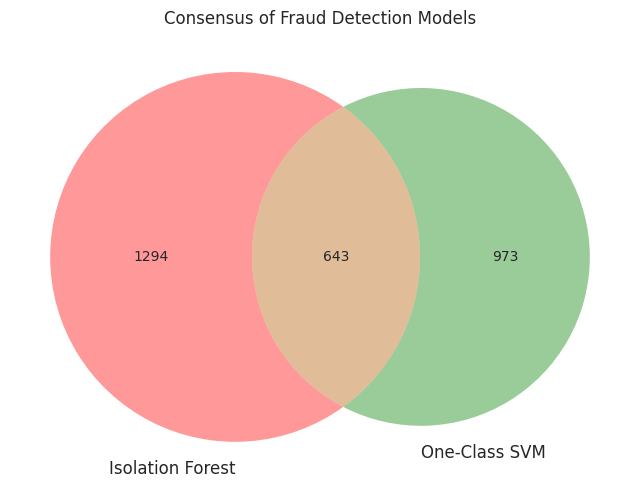

In [388]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Create a Venn Diagram of the Flags
plt.figure(figsize=(8, 8))
venn = venn2(subsets = (
    len(df_ml[df_ml['anomaly_flag'] == -1]), # Isolation Forest only
    len(df_ml[df_ml['svm_flag'] == -1]),     # SVM only
    len(df_ml[df_ml['high_confidence_fraud'] == True]) # Both
), set_labels = ('Isolation Forest', 'One-Class SVM'))

plt.title("Consensus of Fraud Detection Models")
plt.show()

# Elliptic Envelope
* Applies the Elliptic Envelope model to detect anomalies based on statistical distribution. The data is first cleaned and standardised to ensure consistency across features. The model then fits an elliptical boundary around the normal data points and identifies those lying outside this boundary as anomalies.

In [389]:
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Standard Scaler
# This uses Mean and Standard Deviation: (x - mean) / std
std_scaler = StandardScaler()

# 2. Fit and Transform the ML features
# Make sure df_ml is cleaned of Infinities first!
df_ml[features_svm] = df_ml[features_svm].replace([np.inf, -np.inf], -100).fillna(-100)
scaled_std_data = std_scaler.fit_transform(df_ml[features_svm])

# 3. Initialize the Elliptic Envelope
# We keep contamination at 0.03 for a fair comparison
ee_std_model = EllipticEnvelope(contamination=0.03, random_state=42)

# 4. Fit the model to the Standard-Scaled data
df_ml['ee_std_flag'] = ee_std_model.fit_predict(scaled_std_data)

# 5. Get the Decision Score (Statistical Distance)
df_ml['ee_std_score'] = ee_std_model.decision_function(scaled_std_data)

print(f"Standard-Scaled EE flagged: {len(df_ml[df_ml['ee_std_flag'] == -1])} vehicles")

Standard-Scaled EE flagged: 971 vehicles


#Testing
* Testing our models on the validation dataset. which we have created by using the poisend data and getting negative mileage and normal data from the dataset.

In [390]:
# 1. Prepare the Forensic Features for IF
# We use the same list of features you defined in your code
features_if = ['mileage_diff', 'miles_per_day', 'usage_trend_shift', 'usage_consistency_ratio', 'car_age_at_test']

# Handle any infinities in the forensic set (just like we did for training)
X_forensic_if = df_forensic_test[features_if].replace([np.inf, -np.inf], -100).fillna(-100)

# 2. Predict on Forensic Data
# iso_model is already fit on your df_ml
df_forensic_test['if_prediction_raw'] = iso_model.predict(X_forensic_if)

# 3. Map to match your 'ground_truth' (0=Normal, 1=Anomaly)
# Isolation Forest outputs -1 for anomaly, 1 for normal
df_forensic_test['if_flag'] = df_forensic_test['if_prediction_raw'].map({1: 0, -1: 1})

print("Isolation Forest Testing Complete.")

Isolation Forest Testing Complete.


In [391]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare Features for SVM
features_svm = ['mileage_diff', 'miles_per_day', 'usage_trend_shift', 'car_age_at_test']
X_forensic_svm = df_forensic_test[features_svm].replace([np.inf, -np.inf], -100).fillna(-100)

#  Scale the Forensic data using the PREVIOUSLY FIT scaler
scaled_forensic_svm = scaler_svm.transform(X_forensic_svm)

# Predict on Forensic Data
df_forensic_test['svm_prediction_raw'] = svm_model.predict(scaled_forensic_svm)

# Map to match your 'ground_truth' (0=Normal, 1=Anomaly)
df_forensic_test['svm_flag'] = df_forensic_test['svm_prediction_raw'].map({1: 0, -1: 1})

print("One-Class SVM Testing Complete.")

One-Class SVM Testing Complete.


In [392]:
# Define the features used for LOF (must match your training set)
features_lof = ['mileage_diff',
    'usage_trend_shift',
    'usage_consistency_ratio',
    'car_age_at_test']


#  Prepare Forensic Test Set Data Cleaning
X_forensic_lof = df_forensic_test[features_lof].replace([np.inf, -np.inf], -10).fillna(0)

# Scaling
X_forensic_lof_scaled = scaler.transform(X_forensic_lof)

#  Predict on Forensic Data

df_forensic_test['lof_prediction_raw'] = lof.fit_predict(X_forensic_lof_scaled)

#  Map results to match Ground Truth

# Ground Truth uses: 1 (Anomaly), 0 (Normal)
df_forensic_test['lof_flag'] = df_forensic_test['lof_prediction_raw'].map({1: 0, -1: 1})




In [393]:
#  Use the same features defined in your EE training cell

X_forensic_ee = df_forensic_test[features_svm].replace([np.inf, -np.inf], -100).fillna(-100)

#  Transform the forensic data using the Standard Scaler

X_forensic_ee_scaled = std_scaler.transform(X_forensic_ee)

#  Predict on Forensic Data

df_forensic_test['ee_prediction_raw'] = ee_std_model.predict(X_forensic_ee_scaled)

#  Map to match Ground Truth (1 = Normal, -1 = Anomaly -> 0 = Normal, 1 = Anomaly)
df_forensic_test['ee_flag'] = df_forensic_test['ee_prediction_raw'].map({1: 0, -1: 1})



# Model Evaluation and Visualization

* we calculate key performance metrics to evaluate how well each anomaly detection model performs.

* We define a function that computes: Accuracy, Precision, Recall, F1-Score
* We then apply this function to each model:Isolation Forest,One-Class SVM, Local Outlier Factor (LOF), Elliptic Envelope

In [423]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Function to display the 'Report Card'
def get_model_stats(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"--- {model_name} Statistics ---")
    print(f"Accuracy:  {acc:.2%}")
    print(f"Precision: {prec:.2%}") # How many 'flags' were actually fraud
    print(f"Recall:    {rec:.2%}")    # How many of the 600 you actually caught
    print(f"F1-Score:  {f1:.2%}")     # The balance between Precision and Recall
    print("-" * 30)

# Run it for your results
get_model_stats(df_forensic_test['ground_truth'], df_forensic_test['if_flag'], "Isolation Forest")
get_model_stats(df_forensic_test['ground_truth'], df_forensic_test['svm_flag'], "One-Class SVM")
get_model_stats(df_forensic_test['ground_truth'], df_forensic_test['lof_flag'], "Local Outlier Factor")
get_model_stats(df_forensic_test['ground_truth'], df_forensic_test['ee_flag'], "Elliptic Envelope")

--- Isolation Forest Statistics ---
Accuracy:  88.75%
Precision: 86.17%
Recall:    69.34%
F1-Score:  76.84%
------------------------------
--- One-Class SVM Statistics ---
Accuracy:  94.12%
Precision: 90.56%
Recall:    87.25%
F1-Score:  88.87%
------------------------------
--- Local Outlier Factor Statistics ---
Accuracy:  76.51%
Precision: 67.15%
Recall:    24.97%
F1-Score:  36.40%
------------------------------
--- Elliptic Envelope Statistics ---
Accuracy:  80.89%
Precision: 83.65%
Recall:    36.09%
F1-Score:  50.43%
------------------------------


**Confusion matrix:**
* we evaluate the performance of our anomaly detection models by comparing their predictions with the ground truth labels.
* creating a **confusion matrix** to show how many predictions were correct or incorrect

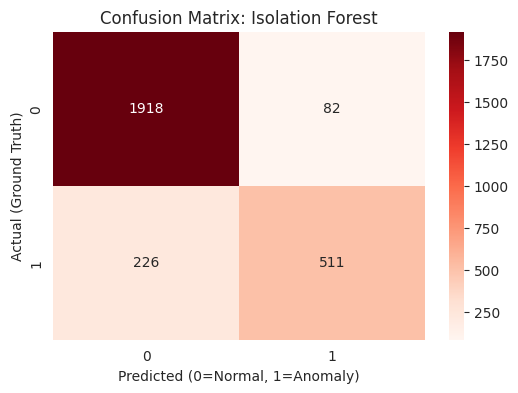


--- Isolation Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.96      0.93      2000
           1       0.86      0.69      0.77       737

    accuracy                           0.89      2737
   macro avg       0.88      0.83      0.85      2737
weighted avg       0.89      0.89      0.88      2737



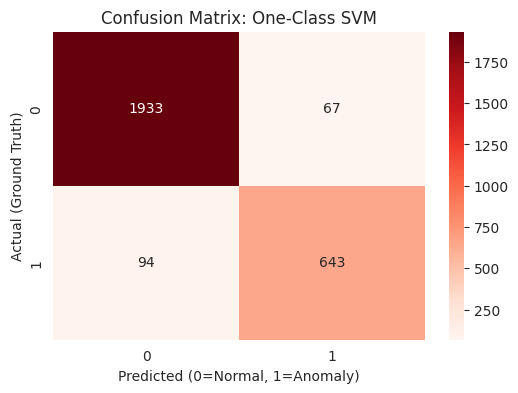


--- One-Class SVM Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2000
           1       0.91      0.87      0.89       737

    accuracy                           0.94      2737
   macro avg       0.93      0.92      0.92      2737
weighted avg       0.94      0.94      0.94      2737



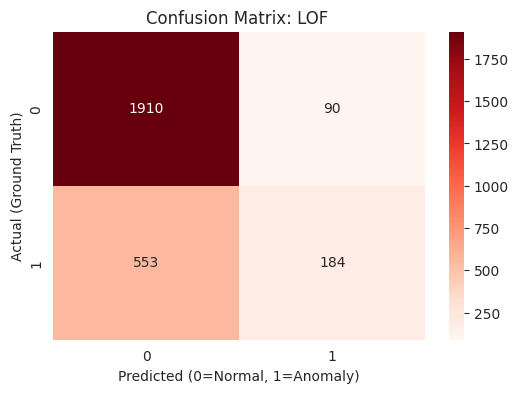


--- LOF  Classification Report ---
              precision    recall  f1-score   support

           0       0.78      0.95      0.86      2000
           1       0.67      0.25      0.36       737

    accuracy                           0.77      2737
   macro avg       0.72      0.60      0.61      2737
weighted avg       0.75      0.77      0.72      2737



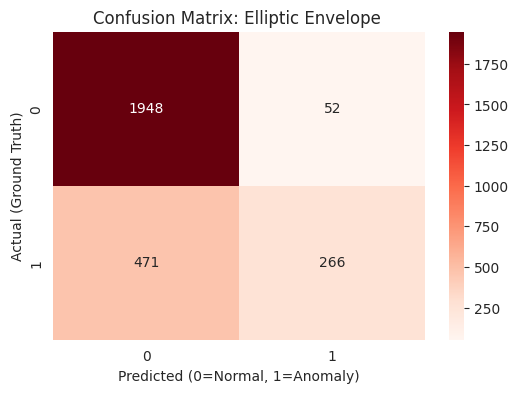


--- Elliptic Envelope  Classification Report ---
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      2000
           1       0.84      0.36      0.50       737

    accuracy                           0.81      2737
   macro avg       0.82      0.67      0.69      2737
weighted avg       0.81      0.81      0.78      2737



In [395]:
def plot_results(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted (0=Normal, 1=Anomaly)')
    plt.ylabel('Actual (Ground Truth)')
    plt.show()

    print(f"\n--- {model_name} Classification Report ---")
    print(classification_report(y_true, y_pred))

# Run for Isolation Forest
plot_results(df_forensic_test['ground_truth'], df_forensic_test['if_flag'], "Isolation Forest")

# Run for One-Class SVM
plot_results(df_forensic_test['ground_truth'], df_forensic_test['svm_flag'], "One-Class SVM")
plot_results(df_forensic_test['ground_truth'], df_forensic_test['lof_flag'], "LOF ")
plot_results(df_forensic_test['ground_truth'], df_forensic_test['ee_flag'], "Elliptic Envelope ")

**Comparing Model Performance:**

* To get a clearer picture of how each model performs, we bring all evaluation metrics together into a single visualization.

* This function calculates accuracy, precision, recall, and F1-score for each model using the test dataset. The results are then organized into a table and displayed as a bar chart

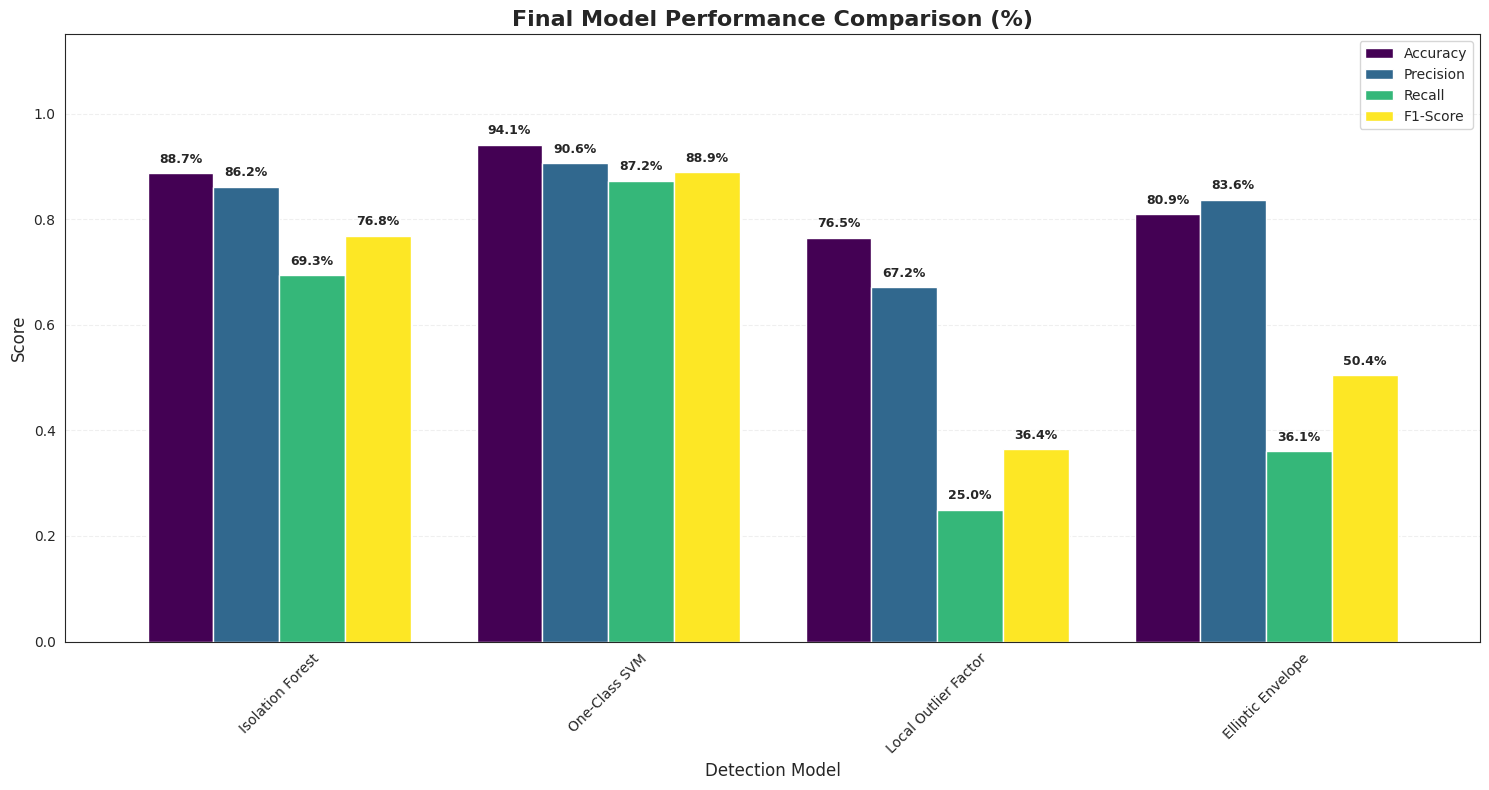

In [417]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def plot_final_metrics_with_labels(test_df):
    # 1. Map models to their prediction columns
    model_map = {
        'Isolation Forest': 'if_flag',
        'One-Class SVM': 'svm_flag',
        'Local Outlier Factor': 'lof_flag',
        'Elliptic Envelope': 'ee_flag'
    }

    y_true = test_df['ground_truth']
    results = []

    # 2. Calculate the "Report Card"
    for name, col in model_map.items():
        y_pred = test_df[col]
        results.append({
            'Model': name,
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred),
            'Recall': recall_score(y_true, y_pred),
            'F1-Score': f1_score(y_true, y_pred)
        })

    # 3. Prepare DataFrame
    res_df = pd.DataFrame(results).set_index('Model')

    # 4. Create the Plot
    ax = res_df.plot(kind='bar', figsize=(15, 8), width=0.8, colormap='viridis')

    plt.title('Final Model Performance Comparison (%)', fontsize=16, fontweight='bold')
    plt.ylabel('Score', fontsize=12)
    plt.xlabel('Detection Model', fontsize=12)
    plt.ylim(0, 1.15) # Extra space for labels
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(loc='upper right', bbox_to_anchor=(1, 1))

    # 5. Add Percentage Labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # Only label bars that have a value
            ax.annotate(f'{height:.1%}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        xytext=(0, 10),
                        textcoords='offset points',
                        fontsize=9,
                        fontweight='bold')

    plt.tight_layout()
    plt.show()

# Run the visualization
plot_final_metrics_with_labels(df_forensic_test)

**Visualising Model Decisions:**

* In this section, we explore how each model classifies data points by plotting them in a two-dimensional space.
* The position is based on mileage difference and usage trend shift
* The colour of the data point indicates whether the model flagged it as normal or anomalous

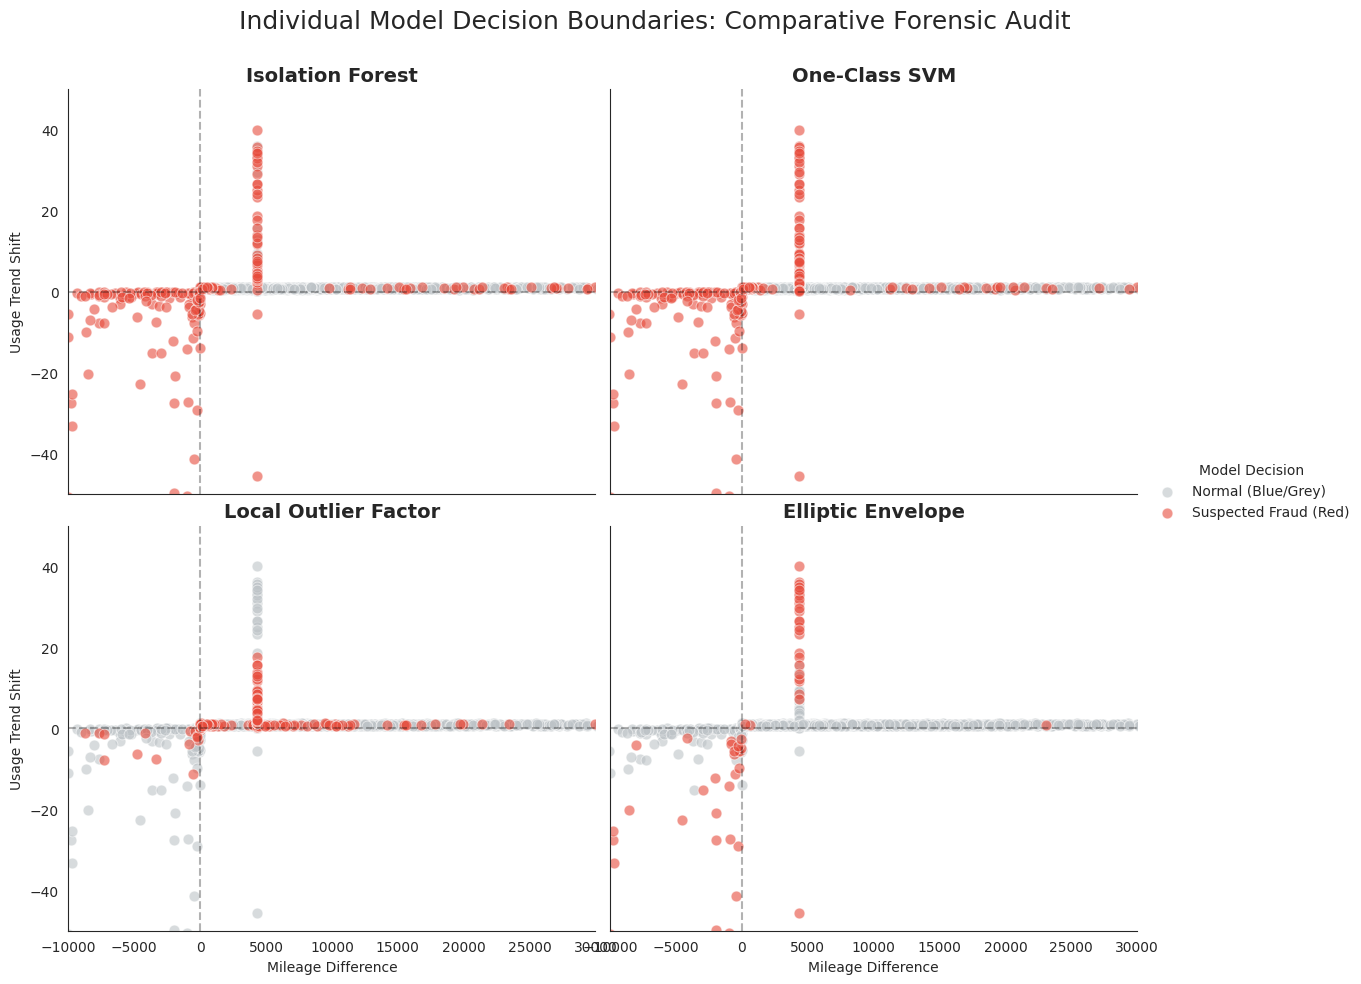

In [421]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Melt the data to a "Long Format" for FacetGrid
# We want a single column for the model name and a single column for the flag
model_cols = {
    'if_flag': 'Isolation Forest',
    'svm_flag': 'One-Class SVM',
    'lof_flag': 'Local Outlier Factor',
    'ee_flag': 'Elliptic Envelope'
}

# Create a temporary dataframe for plotting
plot_data = []
for col, name in model_cols.items():
    temp = df_forensic_test[['mileage_diff', 'usage_trend_shift', 'synthetic_label', col]].copy()
    temp['Model_Name'] = name
    temp.columns = ['mileage_diff', 'usage_trend_shift', 'synthetic_label', 'is_anomaly', 'Model_Name']
    plot_data.append(temp)

df_plot = pd.concat(plot_data)

# 2. Create the FacetGrid
g = sns.FacetGrid(df_plot, col="Model_Name", col_wrap=2, height=5, aspect=1.2, hue="is_anomaly", palette={0: '#bdc3c7', 1: '#e74c3c'})

# 3. Map the scatterplot to each grid
g.map(sns.scatterplot, "mileage_diff", "usage_trend_shift", alpha=0.6, s=60, edgecolor='w')

# 4. Add visual boundaries for context
for ax in g.axes.flat:
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax.set_xlim(-10000, 30000) # Adjust based on your data range
    ax.set_ylim(-50, 50)       # Focus on the trend shift area

# 5. Final Polish
g.add_legend(title="Model Decision", labels=['Normal (Blue/Grey)', 'Suspected Fraud (Red)'])
g.set_titles("{col_name}", size=14, fontweight='bold')
g.set_axis_labels("Mileage Difference", "Usage Trend Shift")

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Individual Model Decision Boundaries: Comparative Forensic Audit', fontsize=18)

plt.show()

In [397]:
import joblib
# 1. Save the Isolation Forest
joblib.dump(iso_model, 'isolation_forest_mot_model.pkl')

# 2. Save the One-Class SVM
joblib.dump(svm_model, 'svm_mot_model.pkl')

# 3. Save the Scaler (CRITICAL: You need this to process new data)
joblib.dump(scaler_svm, 'mot_scaler.pkl')

print("All models and scalers saved successfully!")

All models and scalers saved successfully!


# Conclusion
The evaluation demonstrates that One-Class SVM is the superior model for this forensic task, achieving the highest F1-Score (88.87%) and Recall (87.25%). This indicates a high sensitivity to the subtle "Clocked Commuter" patterns injected into the dataset.

Key Findings:

Winner: One-Class SVM provided the best balance, successfully catching the vast majority of frauds while maintaining a high Precision (90.56%), ensuring minimal false accusations against honest drivers.

Strong Runner-Up: Isolation Forest performed well but struggled more with the overlap between normal behavior and subtle anomalies, as seen in its lower recall (69.34%).

Underperformers: Both Local Outlier Factor and Elliptic Envelope showed poor recall (<40%). This suggests that the fraud patterns are not purely statistical outliers or density-based clusters, but rather complex boundary violations that require the high-dimensional mapping capabilities of SVM